# Object Detection with YOLO11 — PCB Defect Detection

In this session we train a YOLO11 object detection model to locate and classify defects on printed circuit boards (PCBs). By the end you will have:

- Explored the DeepPCB dataset and understood its class structure
- Trained a YOLO11n detection model from pretrained weights
- Evaluated per-class mAP and understood what the numbers mean
- Analysed failure cases and connected them back to the class imbalance story from Day 1

**Dataset**: [DeepPCB](https://universe.roboflow.com/tack-hwa-wong-zak5u/deeppcb-4dhir) — 1,500 PCB images, 6 defect classes  
**Model**: YOLO11n (nano) pretrained on COCO, fine-tuned on DeepPCB  
**License**: Dataset CC BY 4.0

---

### Assumed folder layout after Roboflow download

```
deeppcb-4dhir/          ← set DATASET_ROOT below
  train/
    images/
    labels/
  valid/
    images/
    labels/
  test/
    images/
    labels/
  data.yaml
```

## 0. Setup

In [1]:
import os
import sys
print(sys.executable)

/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/bin/python


In [4]:
import tempfile

miopen_dir = tempfile.mkdtemp(prefix="miopen-", dir="/tmp")
os.environ["MIOPEN_USER_DB_PATH"] = miopen_dir
os.environ["MIOPEN_CUSTOM_CACHE_DIR"] = miopen_dir

In [2]:
# Install dependencies (skip if already installed)
#%pip install supervision

In [5]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import supervision as sv
import torch
from ultralytics import YOLO

In [6]:
# ── paths ──────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11")   # ← adjust if your folder is elsewhere
YAML_PATH    = DATASET_ROOT / "data.yaml"

# ── reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── device ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# ── class names (from data.yaml) ───────────────────────────────────────────
CLASS_NAMES = ['copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']
NC = len(CLASS_NAMES)
print(f"Classes ({NC}): {CLASS_NAMES}")

Using device: cuda
Classes (6): ['copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']


In [7]:
USERNAME = os.environ.get("USER", "unknown")
print(USERNAME)
FLASH_DIR = Path(f"/flash/project_465002387/MS_YOLO/{USERNAME}")
FLASH_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR = FLASH_DIR / "runs/detect/deeppcb_yolo11n"

xieruiwe


## 1. Exploratory Data Analysis

Before training anything, we look at the data. The key questions are:

1. How many images and annotations do we have per split?
2. Are the defect classes balanced, or does the model face a class imbalance problem?
3. What do the defects actually look like — and how do their sizes differ across classes?

Answering these shapes every downstream decision: augmentation strategy, evaluation metric choice, and how to interpret the final mAP table.

### 1.1 Dataset size

In [8]:
def count_split(split: str):
    img_dir   = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"
    n_images  = len(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))
    n_labels  = len(list(label_dir.glob("*.txt")))
    return n_images, n_labels

for split in ["train", "valid", "test"]:
    imgs, labels = count_split(split)
    print(f"{split:6s}: {imgs:4d} images, {labels:4d} label files")

train : 3150 images, 3150 label files
valid :  150 images,  150 label files
test  :  300 images,  300 label files


### 1.2 Class distribution

Each YOLO label file contains one row per defect instance: `class_id cx cy w h`.  
We read every training label and count instances per class.

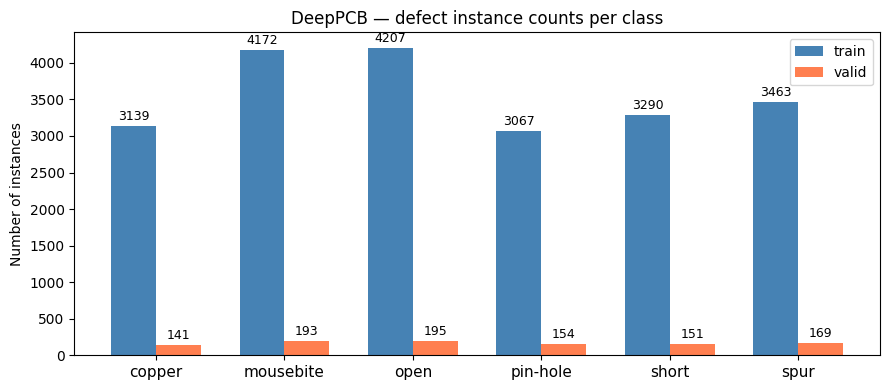


Class imbalance ratio (max / min instances in train):
  1.4×


In [9]:
def count_instances(split: str):
    """Return array of shape (NC,) with per-class instance counts."""
    counts = np.zeros(NC, dtype=int)
    label_dir = DATASET_ROOT / split / "labels"
    for f in label_dir.glob("*.txt"):
        for line in f.read_text().strip().splitlines():
            if line:
                cls = int(line.split()[0])
                counts[cls] += 1
    return counts

train_counts = count_instances("train")
valid_counts = count_instances("valid")

# ── plot ───────────────────────────────────────────────────────────────────
x = np.arange(NC)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
bars_t = ax.bar(x - width/2, train_counts, width, label="train", color="steelblue")
bars_v = ax.bar(x + width/2, valid_counts, width, label="valid",  color="coral")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel("Number of instances")
ax.set_title("DeepPCB — defect instance counts per class")
ax.legend()
ax.bar_label(bars_t, padding=2, fontsize=9)
ax.bar_label(bars_v, padding=2, fontsize=9)
plt.tight_layout()
plt.show()

print("\nClass imbalance ratio (max / min instances in train):")
print(f"  {train_counts.max() / train_counts.min():.1f}×")

**Discussion**: Compare this distribution with the Severstal dataset from Day 1. DeepPCB is much more balanced across classes — a deliberate choice by the dataset creators who augmented rare defect types artificially. Does that mean the detection problem is easier?

### 1.3 What do the defects look like?

This is the most important EDA step: we need to see the actual defects before designing or evaluating any model.

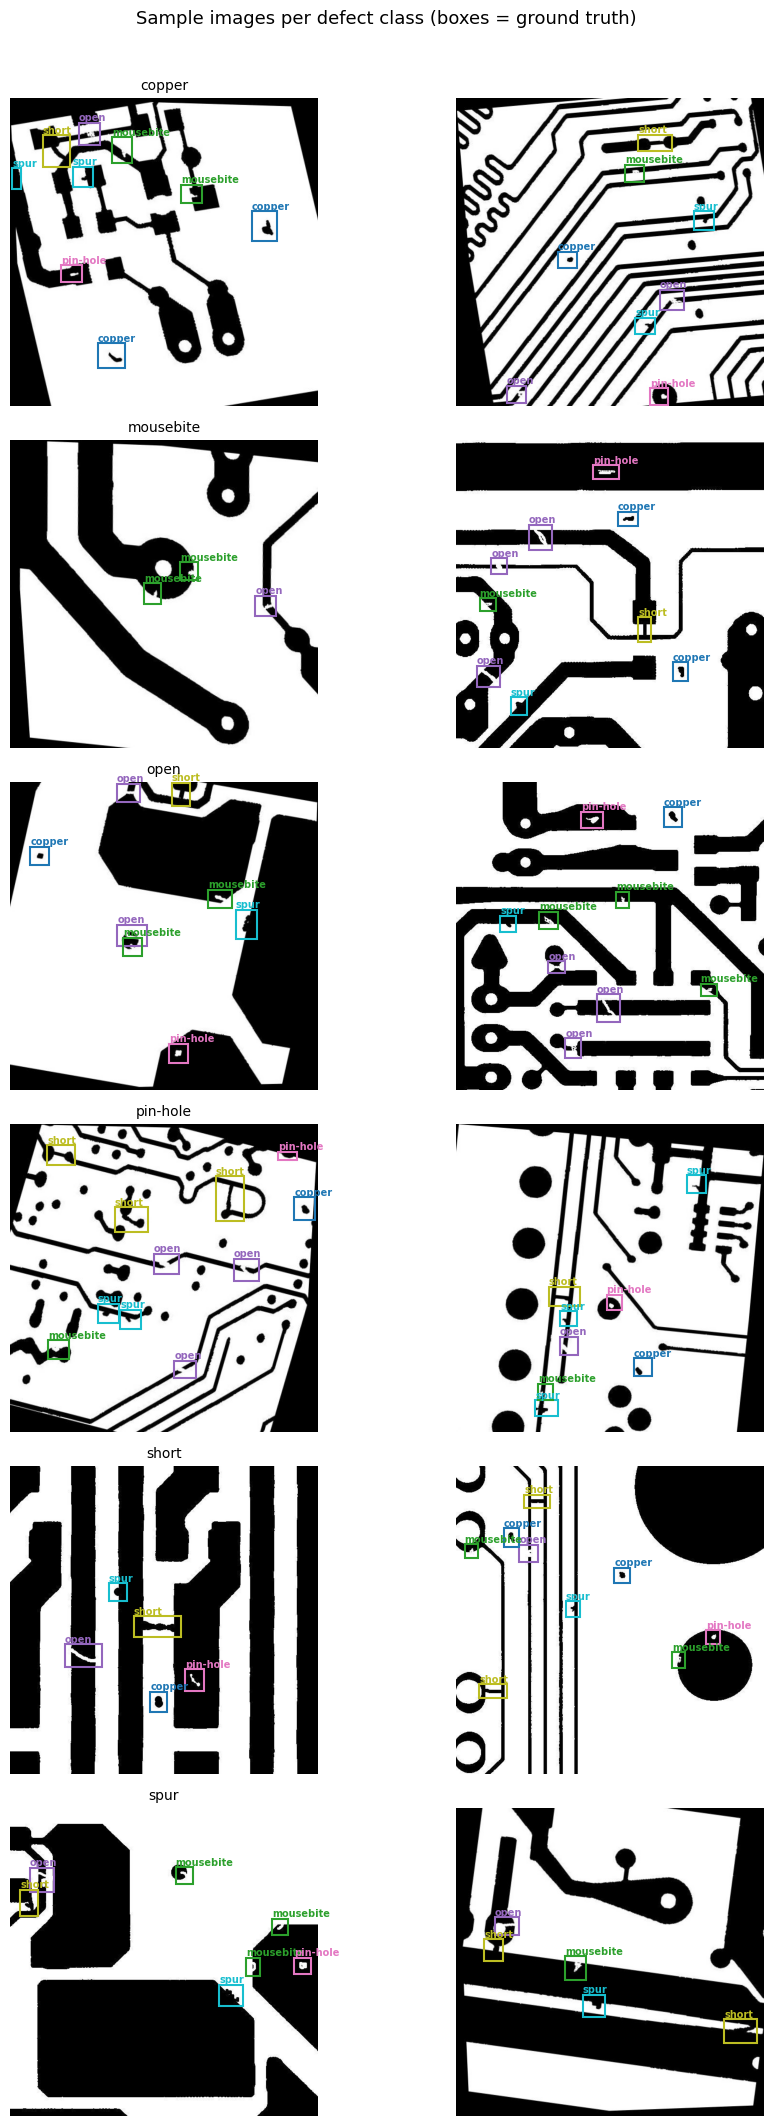

In [10]:
def load_labels(label_path: Path, img_w: int, img_h: int):
    """Parse a YOLO label file → list of (class_id, x1, y1, x2, y2) in pixels."""
    boxes = []
    for line in label_path.read_text().strip().splitlines():
        if not line:
            continue
        parts = line.split()
        cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:5])
        x1 = int((cx - w/2) * img_w)
        y1 = int((cy - h/2) * img_h)
        x2 = int((cx + w/2) * img_w)
        y2 = int((cy + h/2) * img_h)
        boxes.append((cls, x1, y1, x2, y2))
    return boxes

COLORS = plt.cm.tab10(np.linspace(0, 1, NC))

def show_sample_per_class(n_samples: int = 2):
    """Display n_samples images for each defect class."""
    img_dir   = DATASET_ROOT / "train" / "images"
    label_dir = DATASET_ROOT / "train" / "labels"

    # Build index: class_id → list of image stems that contain it
    class_to_stems = {c: [] for c in range(NC)}
    for lf in label_dir.glob("*.txt"):
        classes_in_file = set()
        for line in lf.read_text().strip().splitlines():
            if line:
                classes_in_file.add(int(line.split()[0]))
        for c in classes_in_file:
            class_to_stems[c].append(lf.stem)

    fig, axes = plt.subplots(NC, n_samples, figsize=(5 * n_samples, 3.5 * NC))
    fig.suptitle("Sample images per defect class (boxes = ground truth)",
                 fontsize=13, y=1.01)

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        stems = random.sample(class_to_stems[cls_id],
                              min(n_samples, len(class_to_stems[cls_id])))
        for col, stem in enumerate(stems):
            ax = axes[cls_id][col]
            # find image file (jpg or png)
            img_path = next(
                (img_dir / f"{stem}{ext}" for ext in [".jpg", ".png"]
                 if (img_dir / f"{stem}{ext}").exists()), None)
            if img_path is None:
                ax.axis("off"); continue

            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            boxes = load_labels(label_dir / f"{stem}.txt", w, h)

            ax.imshow(img)
            for (c, x1, y1, x2, y2) in boxes:
                color = COLORS[c]
                rect = mpatches.FancyBboxPatch(
                    (x1, y1), x2-x1, y2-y1,
                    boxstyle="square,pad=0",
                    linewidth=1.5, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 3, CLASS_NAMES[c],
                        color=color, fontsize=7, fontweight="bold")
            ax.set_title(f"{cls_name}" if col == 0 else "", fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_per_class(n_samples=2)

### 1.4 Defect size distribution

Defect size (bounding box area as a fraction of image area) varies significantly across classes. Smaller defects are harder to detect — this will show up in per-class mAP later.

/tmp/ipykernel_60970/3827458826.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=CLASS_NAMES, patch_artist=True,


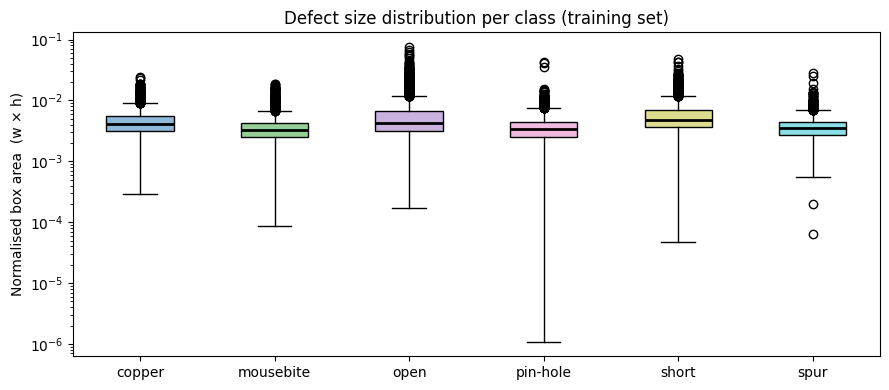

Median normalised area per class:
  copper      : 0.00410
  mousebite   : 0.00322
  open        : 0.00432
  pin-hole    : 0.00342
  short       : 0.00482
  spur        : 0.00351


In [11]:
# Collect normalised box areas (w * h, already in [0,1]) per class
areas_per_class = {c: [] for c in range(NC)}

label_dir = DATASET_ROOT / "train" / "labels"
for lf in label_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if not line: continue
        parts = line.split()
        cls, w, h = int(parts[0]), float(parts[3]), float(parts[4])
        areas_per_class[cls].append(w * h)

fig, ax = plt.subplots(figsize=(9, 4))
data    = [areas_per_class[c] for c in range(NC)]
bp = ax.boxplot(data, labels=CLASS_NAMES, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor((*color[:3], 0.5))
ax.set_ylabel("Normalised box area  (w × h)")
ax.set_title("Defect size distribution per class (training set)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("Median normalised area per class:")
for c, name in enumerate(CLASS_NAMES):
    med = np.median(areas_per_class[c]) if areas_per_class[c] else 0
    print(f"  {name:12s}: {med:.5f}")

**Discussion**: Which classes have the smallest defects? Predict which classes will have the lowest mAP before training. We will revisit this after evaluation.

Also notice: even with balanced instance counts (Section 1.2), the *detection difficulty* is not equal across classes. This is why mAP per class is more informative than overall accuracy.

### 1.5 YOLO label format — one worked example

Before training, let's read one label file raw so the format is concrete.

In [12]:
sample_label = next((DATASET_ROOT / "train" / "labels").glob("*.txt"))
print(f"Label file: {sample_label.name}")
print("─" * 50)
print(sample_label.read_text())
print("─" * 50)
print("Format: <class_id>  <cx>  <cy>  <w>  <h>")
print("All coordinates are normalised to [0, 1] relative to image dimensions.")

Label file: 00041025_test_jpg.rf.057335d01873060ed59362ce11e9b693.txt
──────────────────────────────────────────────────
2 0.4637068700586778 0.274061676815055 0.09160210424747908 0.10570796382236297
4 0.6876652605286822 0.23676102869261173 0.08662577898771542 0.07391418703849752
1 0.9202963292862216 0.3175748161481008 0.06957920274782323 0.06444696424873823
5 0.6904357818275272 0.16330539289157192 0.06791807317971692 0.06433080675381547
1 0.9288878675179938 0.21308042728019358 0.06940509052429114 0.06112470511252561
0 0.56207462896795 0.6193963119965503 0.0713273884276952 0.0662242513117673
3 0.7363462277852499 0.3129869820522044 0.06748279262088745 0.056025158913283905
2 0.17341039592130034 0.024538851232765918 0.06442876526452758 0.02933092832866013
──────────────────────────────────────────────────
Format: <class_id>  <cx>  <cy>  <w>  <h>
All coordinates are normalised to [0, 1] relative to image dimensions.


## 2. Training

We fine-tune **YOLO11n** (nano — smallest and fastest variant) starting from COCO pretrained weights.  
Starting pretrained rather than from scratch gives much better results in 30 epochs on a small dataset like DeepPCB.

Training is launched in the cell below. **While it runs**, refer to the slides for:
- What the FPN backbone does (multi-scale feature extraction)
- What `box_loss`, `cls_loss`, and `dfl_loss` mean in the log output
- How the anchor-free detection head differs from anchor-based YOLO versions

In [13]:
# Verify data.yaml is found and has correct structure before launching
import yaml
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)
print("data.yaml contents:")
for k, v in cfg.items():
    print(f"  {k}: {v}")
assert cfg.get("nc") == NC, f"Expected nc={NC}, got {cfg.get('nc')}"
print("\n✓ data.yaml looks correct")

data.yaml contents:
  path: /projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11
  train: train/images
  val: valid/images
  test: test/images
  nc: 6
  names: ['copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']
  roboflow: {'workspace': 'tack-hwa-wong-zak5u', 'project': 'deeppcb-4dhir', 'version': 5, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/tack-hwa-wong-zak5u/deeppcb-4dhir/dataset/5'}

✓ data.yaml looks correct


In [14]:
YOLO_WEIGHTS = Path("/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/yolo11n.pt")

In [15]:
model = YOLO(str(YOLO_WEIGHTS))

results = model.train(
    data    = str(YAML_PATH),
    epochs  = 30,
    imgsz   = 640,
    batch   = 16,
    device  = DEVICE,
    workers = 2,
    patience= 10,       # early stopping if val mAP doesn't improve for 10 epochs
    seed    = SEED,
    project = str(FLASH_DIR / "runs/detect"),
    name    = "deeppcb_yolo11n",
    exist_ok= True,
    verbose = True,
)

#RUN_DIR = Path(results.save_dir)
print(f"\nTraining complete. Outputs saved to: {RUN_DIR}")

New https://pypi.org/project/ultralytics/8.4.164 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

### 2.1 Training curves

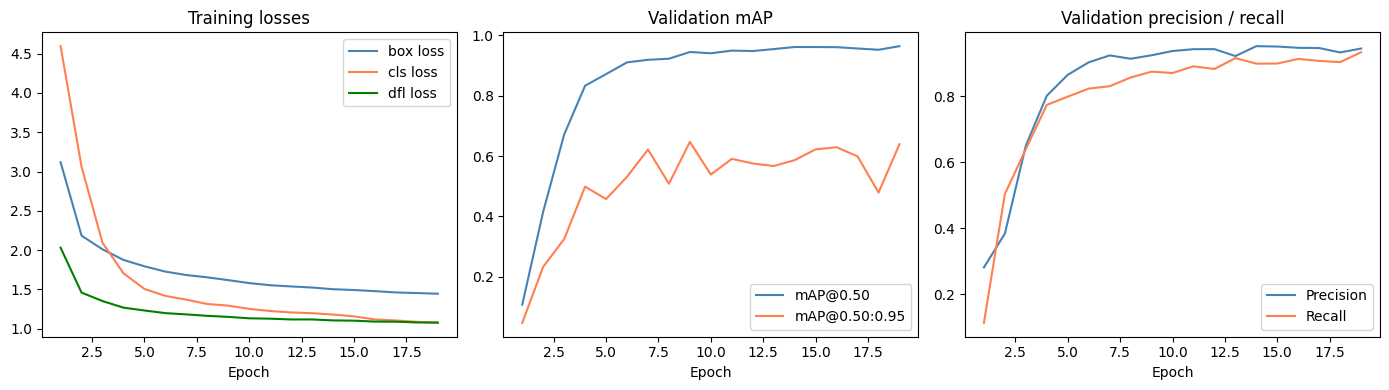

In [16]:
import pandas as pd

metrics_csv = RUN_DIR / "results.csv"
df = pd.read_csv(metrics_csv)
df.columns = df.columns.str.strip()   # Ultralytics sometimes pads column names

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# losses
for col, label, color in [
    ("train/box_loss", "box loss",  "steelblue"),
    ("train/cls_loss", "cls loss",  "coral"),
    ("train/dfl_loss", "dfl loss",  "green"),
]:
    if col in df.columns:
        axes[0].plot(df["epoch"], df[col], label=label, color=color)
axes[0].set_title("Training losses")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# mAP
for col, label, color in [
    ("metrics/mAP50(B)",    "mAP@0.50",    "steelblue"),
    ("metrics/mAP50-95(B)", "mAP@0.50:0.95", "coral"),
]:
    if col in df.columns:
        axes[1].plot(df["epoch"], df[col], label=label, color=color)
axes[1].set_title("Validation mAP")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# precision / recall
for col, label, color in [
    ("metrics/precision(B)", "Precision", "steelblue"),
    ("metrics/recall(B)",    "Recall",    "coral"),
]:
    if col in df.columns:
        axes[2].plot(df["epoch"], df[col], label=label, color=color)
axes[2].set_title("Validation precision / recall")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Evaluation

We load the best checkpoint and run the full validation suite.

### 3.1 Per-class mAP

In [17]:
import yaml
from pathlib import Path

# Print the resolved paths Ultralytics will actually look for
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

print("data.yaml contents:")
print(yaml.dump(cfg))

base = Path(cfg.get("path", ""))
for split in ["train", "val", "test"]:
    raw  = cfg.get(split, "")
    resolved = (base / raw) if not Path(raw).is_absolute() else Path(raw)
    exists = resolved.exists()
    print(f"{split}: '{raw}' → {resolved} → exists={exists}")

data.yaml contents:
names:
- copper
- mousebite
- open
- pin-hole
- short
- spur
nc: 6
path: /projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11
roboflow:
  license: CC BY 4.0
  project: deeppcb-4dhir
  url: https://universe.roboflow.com/tack-hwa-wong-zak5u/deeppcb-4dhir/dataset/5
  version: 5
  workspace: tack-hwa-wong-zak5u
test: test/images
train: train/images
val: valid/images

train: 'train/images' → /projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11/train/images → exists=True
val: 'valid/images' → /projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11/valid/images → exists=True
test: 'test/images' → /projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11/test/images → exists=True


In [19]:
best_weights = RUN_DIR / "weights" / "best.pt"
model_eval   = YOLO(str(best_weights))

val_results = model_eval.val(
    data   = str(YAML_PATH),
    split  = "val",
    device = DEVICE,
    verbose= False,
)

# Per-class AP@50
ap50_per_class = val_results.box.ap50          # shape: (NC,)
map50_overall  = val_results.box.map50
map5095_overall= val_results.box.map

print(f"Overall mAP@0.50      : {map50_overall:.4f}")
print(f"Overall mAP@0.50:0.95 : {map5095_overall:.4f}")
print()
print(f"{'Class':<14} {'AP@0.50':>10}")
print("─" * 26)
for name, ap in zip(CLASS_NAMES, ap50_per_class):
    print(f"{name:<14} {ap:>10.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 522.8±381.8 MB/s, size: 37.7 KB)
val: Scanning /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/Yolo_Detection/DeepPCB.v5i.yolov11/valid/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 62.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.9it/s 5.2s.3s
                   all        150       1003      0.925      0.875      0.945      0.647
Speed: 1.1ms preprocess, 25.7ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /pfs/lustrep4/users/xieruiwe/YOLO_1001_test/runs/detect/val
Overall mAP@0.50      : 0.9452
Overall mAP@0.50:0.95 : 0.6475

Class             AP@0.50
──────────────────────────
copper      

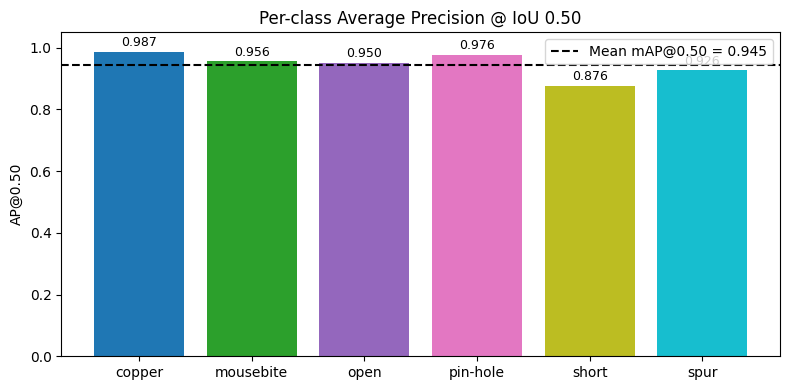

In [20]:
# Visualise per-class AP@50
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASS_NAMES, ap50_per_class,
              color=[COLORS[i] for i in range(NC)])
ax.axhline(map50_overall, color="black", linestyle="--",
           label=f"Mean mAP@0.50 = {map50_overall:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("AP@0.50")
ax.set_title("Per-class Average Precision @ IoU 0.50")
ax.legend()
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
plt.tight_layout()
plt.show()

**Discussion**: Compare this with your predictions from Section 1.4.  
- Which classes underperform? Does that match their median defect size?  
- What is the gap between mAP@0.50 and mAP@0.50:0.95? Why does it exist?

### 3.2 Confusion matrix

Ultralytics saves a confusion matrix image during training. Let's load it.

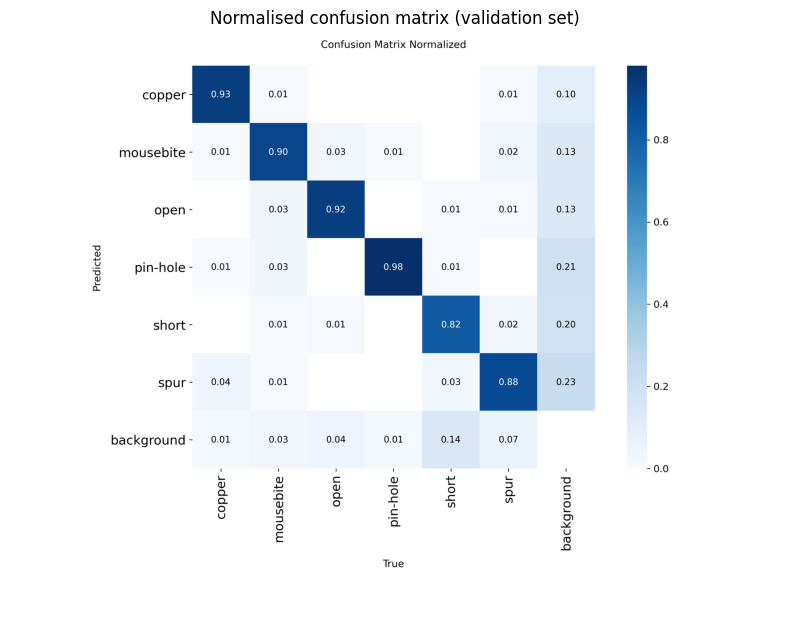

In [21]:
cm_path = RUN_DIR / "confusion_matrix_normalized.png"
if cm_path.exists():
    img = cv2.cvtColor(cv2.imread(str(cm_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Normalised confusion matrix (validation set)")
    plt.tight_layout()
    plt.show()
else:
    print(f"Confusion matrix not found at {cm_path}")
    print("Check the run directory:", RUN_DIR)

### 3.3 Qualitative results — predictions vs ground truth

Numbers alone don't tell the full story. We visualise model predictions alongside ground truth on a sample of validation images.

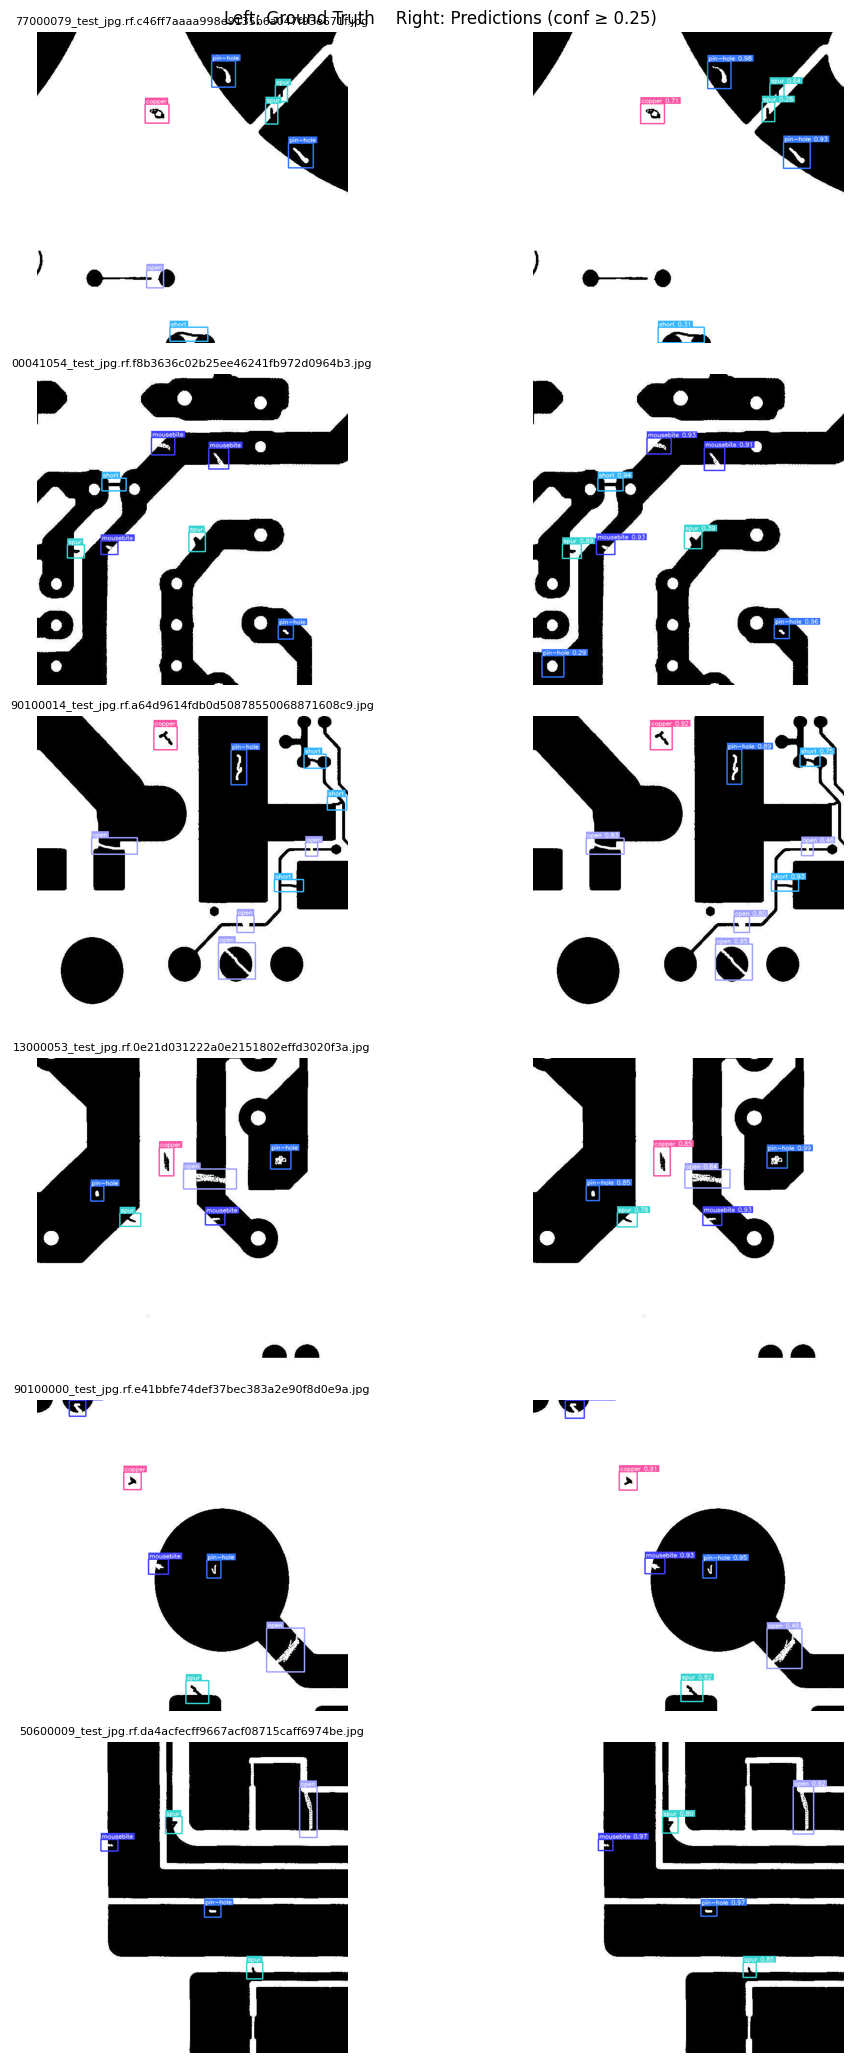

In [22]:
CONF_THRESHOLD = 0.25   # ← try adjusting this in the next section

val_img_dir   = DATASET_ROOT / "valid" / "images"
val_label_dir = DATASET_ROOT / "valid" / "labels"
val_images    = sorted(val_img_dir.glob("*.jpg")) + sorted(val_img_dir.glob("*.png"))
samples       = random.sample(val_images, min(6, len(val_images)))

# supervision annotators
box_ann   = sv.BoxAnnotator(thickness=2)
label_ann = sv.LabelAnnotator(text_scale=0.4, text_padding=2)

fig, axes = plt.subplots(len(samples), 2,
                         figsize=(12, 3.5 * len(samples)))
fig.suptitle(f"Left: Ground Truth    Right: Predictions (conf ≥ {CONF_THRESHOLD})",
             fontsize=12)

for row, img_path in enumerate(samples):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    # ── ground truth ────────────────────────────────────────────────────
    lf    = val_label_dir / (img_path.stem + ".txt")
    boxes = load_labels(lf, w, h) if lf.exists() else []
    gt_img = img_rgb.copy()
    if boxes:
        xyxy    = np.array([[x1,y1,x2,y2] for _,x1,y1,x2,y2 in boxes])
        cls_ids = np.array([c for c,*_ in boxes])
        det_gt  = sv.Detections(xyxy=xyxy, class_id=cls_ids)
        lbls_gt = [CLASS_NAMES[c] for c in cls_ids]
        gt_img  = box_ann.annotate(gt_img.copy(), det_gt)
        gt_img  = label_ann.annotate(gt_img, det_gt, lbls_gt)

    # ── predictions ─────────────────────────────────────────────────────
    pred     = model_eval.predict(str(img_path), conf=CONF_THRESHOLD,
                                  device=DEVICE, verbose=False)[0]
    pred_img = img_rgb.copy()
    if len(pred.boxes):
        det_pred = sv.Detections.from_ultralytics(pred)
        lbls_pred = [
            f"{CLASS_NAMES[c]} {s:.2f}"
            for c, s in zip(det_pred.class_id, det_pred.confidence)
        ]
        pred_img = box_ann.annotate(pred_img.copy(), det_pred)
        pred_img = label_ann.annotate(pred_img, det_pred, lbls_pred)

    axes[row][0].imshow(gt_img);   axes[row][0].axis("off")
    axes[row][1].imshow(pred_img); axes[row][1].axis("off")
    axes[row][0].set_title(img_path.name, fontsize=8)

plt.tight_layout()
plt.show()

### 3.4 Confidence threshold exploration

The confidence threshold is a key operating point decision. Lowering it catches more true defects (higher recall) but also more false positives (lower precision). The right threshold depends on the cost of each error type in the application.

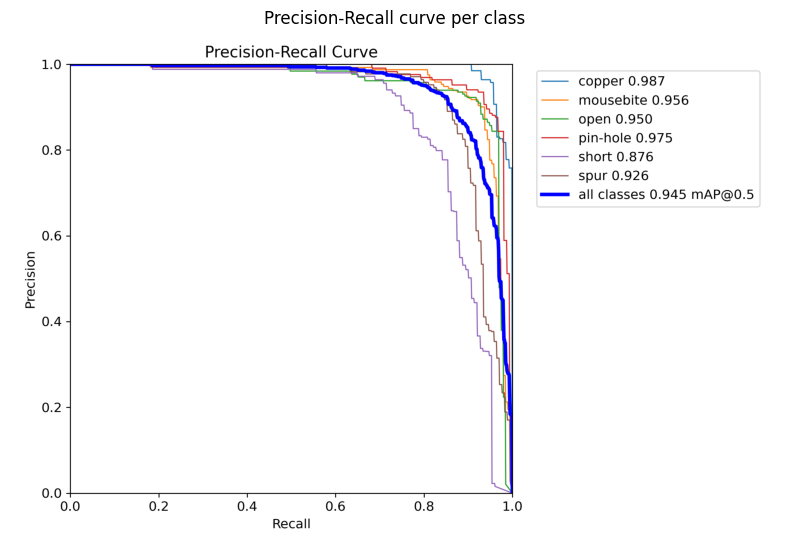

In [28]:
# Plot precision-recall curve from the saved Ultralytics output
pr_path = RUN_DIR / "BoxPR_curve.png"
if pr_path.exists():
    img = cv2.cvtColor(cv2.imread(str(pr_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Precision-Recall curve per class")
    plt.tight_layout()
    plt.show()
else:
    print(f"PR curve not found at {pr_path}")

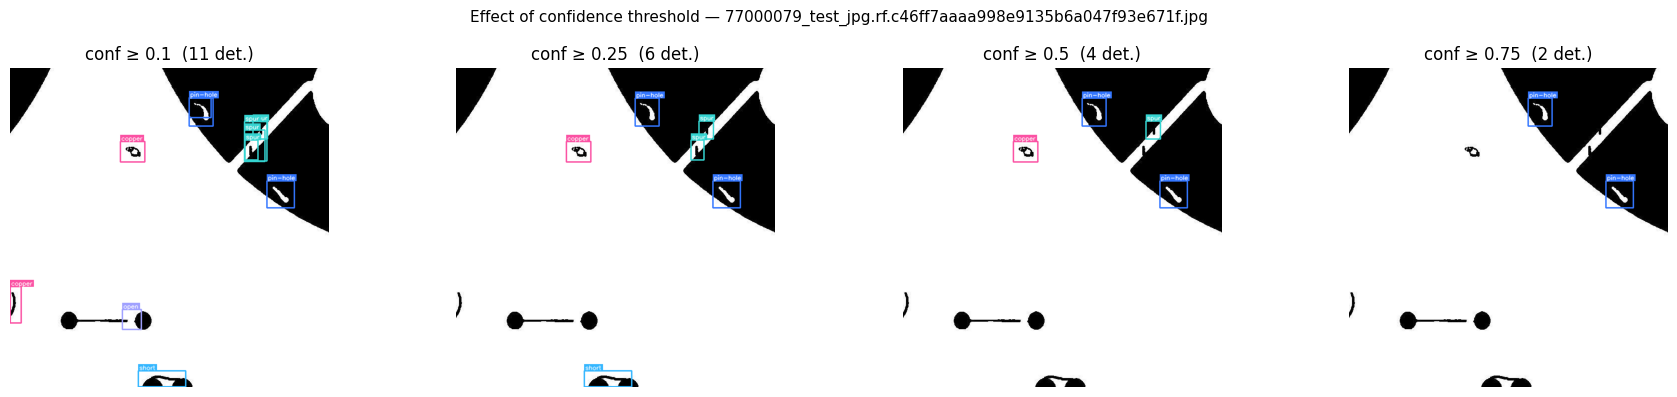

In [24]:
# Manually sweep confidence thresholds and report detection counts on one image
# Pick an image with multiple defect types
sweep_img = samples[0]
thresholds = [0.10, 0.25, 0.50, 0.75]

fig, axes = plt.subplots(1, len(thresholds),
                         figsize=(4.5 * len(thresholds), 4))
fig.suptitle(f"Effect of confidence threshold — {sweep_img.name}", fontsize=11)

for ax, thr in zip(axes, thresholds):
    pred    = model_eval.predict(str(sweep_img), conf=thr,
                                 device=DEVICE, verbose=False)[0]
    img_rgb = cv2.cvtColor(cv2.imread(str(sweep_img)), cv2.COLOR_BGR2RGB)
    if len(pred.boxes):
        det = sv.Detections.from_ultralytics(pred)
        lbls = [f"{CLASS_NAMES[c]}" for c in det.class_id]
        img_rgb = box_ann.annotate(img_rgb.copy(), det)
        img_rgb = label_ann.annotate(img_rgb, det, lbls)
    n = len(pred.boxes)
    ax.imshow(img_rgb)
    ax.set_title(f"conf ≥ {thr}  ({n} det.)")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Discussion**: In a PCB quality control line, which error is more costly — a missed defect (false negative) or a false alarm (false positive)? How would that affect your threshold choice?

## 4. Failure Analysis

The worst-performing class is where the most is to be learned. We deliberately seek out false negatives — defects the model missed.

In [25]:
# Identify the weakest class
worst_cls_id   = int(np.argmin(ap50_per_class))
worst_cls_name = CLASS_NAMES[worst_cls_id]
print(f"Weakest class: '{worst_cls_name}' (AP@0.50 = {ap50_per_class[worst_cls_id]:.4f})")

# Find val images that contain this class in ground truth
val_label_dir = DATASET_ROOT / "valid" / "labels"
worst_stems = []
for lf in val_label_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line and int(line.split()[0]) == worst_cls_id:
            worst_stems.append(lf.stem)
            break
print(f"Found {len(worst_stems)} val images containing '{worst_cls_name}'")

Weakest class: 'short' (AP@0.50 = 0.8763)
Found 114 val images containing 'short'


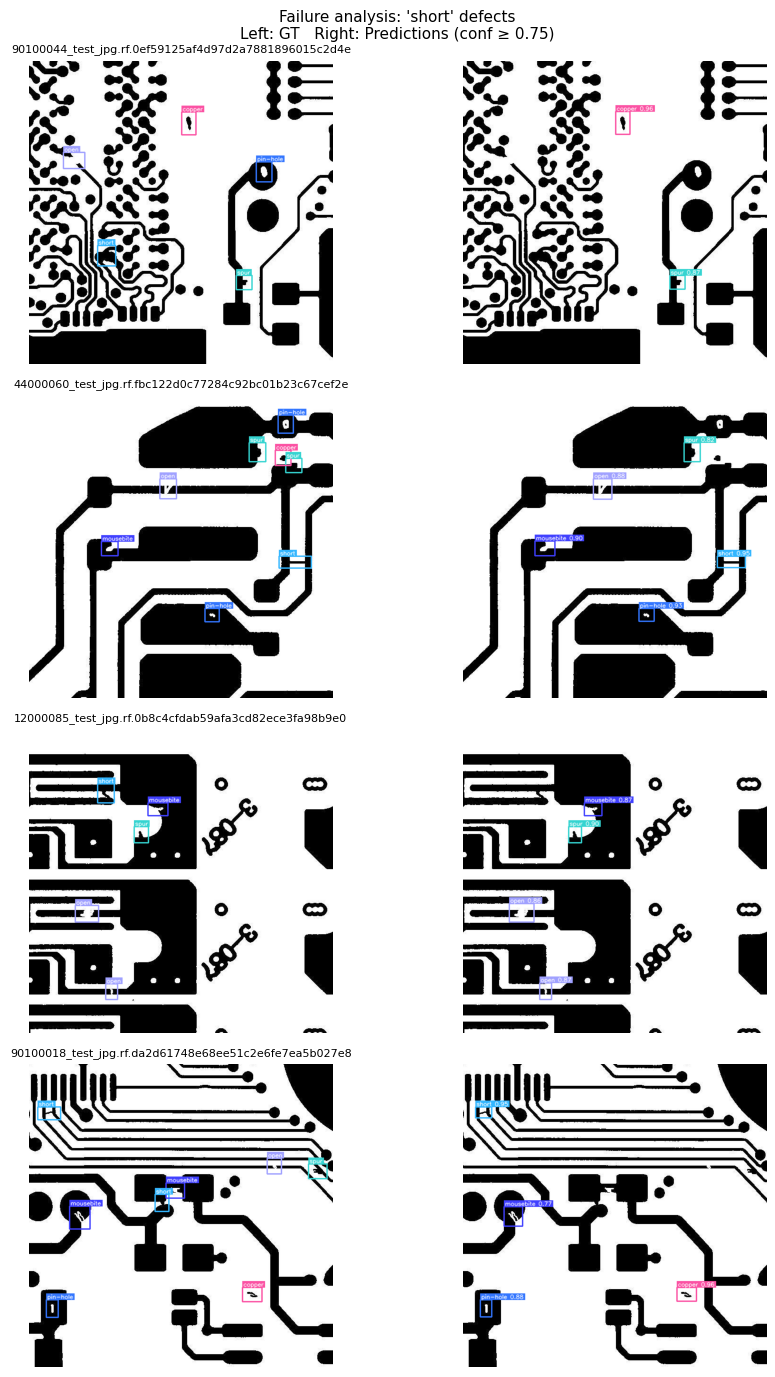

In [26]:
# Show a few images for the weakest class: GT vs prediction
FAIL_CONF = 0.75
val_img_dir = DATASET_ROOT / "valid" / "images"
show_stems  = random.sample(worst_stems, min(4, len(worst_stems)))

fig, axes = plt.subplots(len(show_stems), 2,
                         figsize=(10, 3.5 * len(show_stems)))
fig.suptitle(f"Failure analysis: '{worst_cls_name}' defects\n"
             f"Left: GT   Right: Predictions (conf ≥ {FAIL_CONF})",
             fontsize=11)

for row, stem in enumerate(show_stems):
    img_path = next(
        (val_img_dir / f"{stem}{ext}" for ext in [".jpg", ".png"]
         if (val_img_dir / f"{stem}{ext}").exists()), None)
    if img_path is None:
        continue

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    # GT
    lf     = val_label_dir / f"{stem}.txt"
    boxes  = load_labels(lf, w, h) if lf.exists() else []
    gt_img = img_rgb.copy()
    if boxes:
        xyxy    = np.array([[x1,y1,x2,y2] for _,x1,y1,x2,y2 in boxes])
        cls_ids = np.array([c for c,*_ in boxes])
        det_gt  = sv.Detections(xyxy=xyxy, class_id=cls_ids)
        gt_img  = box_ann.annotate(gt_img, det_gt)
        gt_img  = label_ann.annotate(gt_img, det_gt,
                                     [CLASS_NAMES[c] for c in cls_ids])

    # Prediction
    pred     = model_eval.predict(str(img_path), conf=FAIL_CONF,
                                  device=DEVICE, verbose=False)[0]
    pred_img = img_rgb.copy()
    if len(pred.boxes):
        det_pred = sv.Detections.from_ultralytics(pred)
        pred_img = box_ann.annotate(pred_img, det_pred)
        pred_img = label_ann.annotate(pred_img, det_pred,
            [f"{CLASS_NAMES[c]} {s:.2f}"
             for c, s in zip(det_pred.class_id, det_pred.confidence)])

    axes[row][0].imshow(gt_img);   axes[row][0].axis("off")
    axes[row][1].imshow(pred_img); axes[row][1].axis("off")
    axes[row][0].set_title(stem, fontsize=8)

plt.tight_layout()
plt.show()

**Discussion**: 
- Are the missed defects consistently small? Clustered near image edges? Visually similar to background?
- What would you do to improve performance on this class? (More data? Higher resolution? Augmentation?)

## 5. Wrap-up and Bridge to segmentation

We have trained a YOLO11n model that can **locate and classify** six types of PCB defects. The key outputs are:

| | |
|---|---|
| Overall mAP@0.50 | see Section 3.1 |
| Weakest class | see Section 4 |
| Confidence threshold choice | depends on FP vs FN cost |

### What bounding boxes cannot tell us

Detection gives us **where** a defect is (a rectangle) and **what type** it is.  
It does **not** tell us:

- The exact **shape** of the defect — is it a hairline crack or a wide pit?
- The **area** of the defect — critical for severity scoring
- Whether two adjacent defects are one instance or two

For these questions, we need **instance segmentation** — which is exactly what the later session covers, using the Magnetic Tile Defect dataset.

In [27]:
# Quick summary table
print("=" * 40)
print("  Morning session results summary")
print("=" * 40)
print(f"  Model    : YOLO11n (pretrained COCO)")
print(f"  Dataset  : DeepPCB ({NC} classes)")
print(f"  mAP@0.50 : {map50_overall:.4f}")
print(f"  mAP@0.50:0.95: {map5095_overall:.4f}")
print()
print("  Per-class AP@0.50:")
for name, ap in zip(CLASS_NAMES, ap50_per_class):
    bar = "█" * int(ap * 20)
    print(f"    {name:<12} {ap:.3f}  {bar}")
print("=" * 40)

  Morning session results summary
  Model    : YOLO11n (pretrained COCO)
  Dataset  : DeepPCB (6 classes)
  mAP@0.50 : 0.9452
  mAP@0.50:0.95: 0.6475

  Per-class AP@0.50:
    copper       0.987  ███████████████████
    mousebite    0.956  ███████████████████
    open         0.950  ███████████████████
    pin-hole     0.976  ███████████████████
    short        0.876  █████████████████
    spur         0.926  ██████████████████
